
# Security and Privacy (CC2009) - 25/26
## ASSIGNMENT #1: Performance Benchmarking of Cryptographic Mechanisms
## PL1 - Elements: Amanda Lucas (202400455), Aly Filho (202401045) e Silvia Pinto (202405988)


#### A. Generate random text files with the following sizes: 8, 64, 512, 4096, 32768, 262144, 2097152:
##### &emsp;Done in ../03 - data
##### &emsp;We use the **urandom** from **OS** (Python) to generate random files, can be seen in **../02 - scripts/gen_files.py**
---

#### B. Encrypt and decrypt random files with AES in Counter Mode, using the code that you wrote previously:
&emsp;First thing is to define 2 functions, in Python, one to encrypt and another one to decrypt, using the cryptography library from python: We will use Cipher to define a cipher with AES algorithms from algorithms in CTR mode from modes, that can been seen in **../01 - source/aes_ctr.py**<br>
&emsp;Here function 1 receives m (plaintext), the key and nonce and returns c (ciphertext), and function 2 receives c (ciphertext), the key and nonce and return the original text m (plaintext):

In [6]:
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes

def my_encrypt_aes_ctr(plaintext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 

    encrypt = cypher.encryptor()  
    
    return encrypt.update(plaintext) + encrypt.finalize() 

def my_decrypt_aes_ctr(ciphertext, key, nonce):
    alg = algorithms.AES(key) 
    mode = modes.CTR(nonce) 
    cypher = Cipher(alg,mode) 

    decrypt = cypher.decryptor()

    return decrypt.update(ciphertext) + decrypt.finalize()

&emsp;To ensure statistical significance, we automated the benchmarking process using **Pandas** and **NumPy**. We performed repeated executions over the same files to observe temporal variance and across multiple randomly generated files of fixed sizes to evaluate the algorithm's consistency regardless of the input data. For intuitive graphical analysis we use **Matplotlib** and **Seaborn** libraries.


In [2]:
import sys
sys.path.append('../01 - source')
from aes_ctr import df, plot_variation_same_file, plot_comparison_fixed_size, plot_final_scalability

##### Question B.1) Do results change if you run a fixed algorithm over the same file multiple times?

&emsp;Here we are fixing the algorithm over one unique file, that can be seen in function **plot_variation_same_file** in **aes_ctr.py**, and we encrypt and decrypt this fixed file 30 times.<br>
&emsp;To ensure statistical significance, we chose a sample size of **n = 30** repetitions for each cryptographic operation. According to the Central Limit Theorem, a sample size of 30 is sufficient to approximate a normal distribution, allowing for reliable calculations of the standard deviation and confidence intervals.

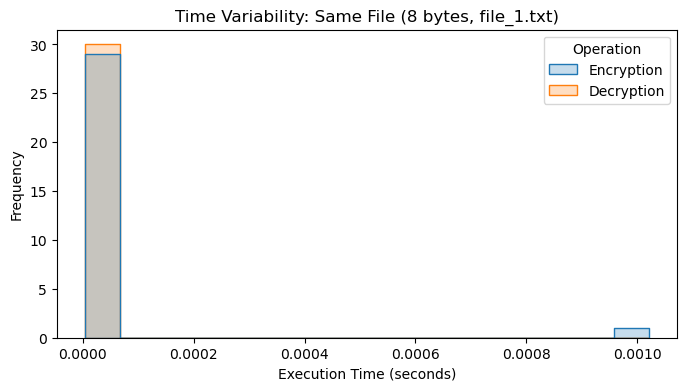

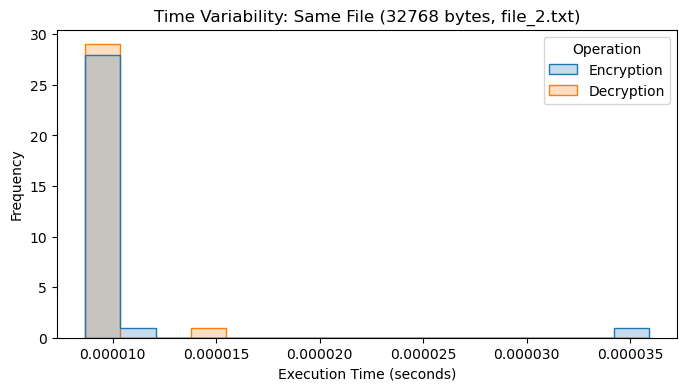

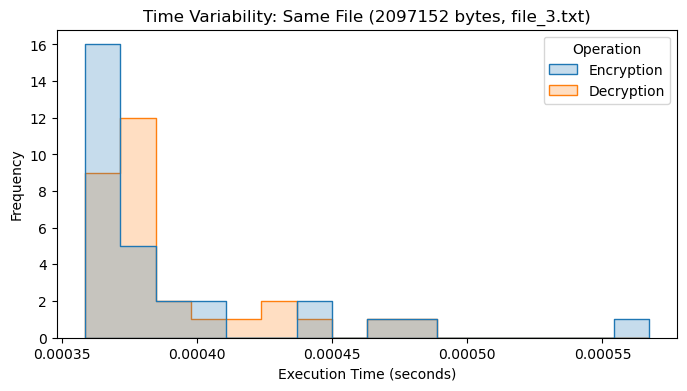

In [3]:
plot_variation_same_file(df,8,'file_1.txt')
plot_variation_same_file(df,32768, 'file_2.txt')
plot_variation_same_file(df,2097152,'file_3.txt')

&emsp;For better analysis let's take a look on performance of a fixed 8 Bytes size (the smaller), 32768 Bytes size (the intermediary) and the 2097152 Bytes size (the bigger), but it can be done with any file size, just calling the function with the desire size in the function parameter. Studying this 3 graphics, we can conclude:
- **Yes, the results change if you run a fixed algorithm over the same file multiple times!** That may seen strange because the AES-CTR is a deterministic algorithm, that is, the same input generates the same output with the same calculations quantify, so why the times isn't the same in every 30 tests of encrypt and decrypt? That's not algorithm fault, the variation occurs because of computational environment, e.g. the O.S. is doing many things ate the same time and while the script Python is working, outers procedures are happen ant thats can cause a noise in time data, called CPU jitter. In the graphics we can notice:
    1) The big bar: Is the rule, shows the real and pure time of algorithm, em almost all tests (28 or 28 times), we can see a pattern of time, without the system noise.
    2) The little bars: They are outliers, show that sometimes the OS parallels procedures can "dirty" the data times.
- Furthermore, the histograms reveal that the absolute variance in execution time increases as the file grows. For an 8 Byte file, the execution is near-instantaneous, fitting entirely within the CPU's L1 cache and completing before the OS scheduler can interrupt it. However, for a 2MB file, the wider spread of execution times (as seen in the flatter histogram) occurs due to two factors: increased probability of OS context switching during the longer execution window, and the latency introduced by memory hierarchy operations, as a 2MB payload requires fetching data from the main memory (RAM) and handling potential cache misses."

##### Question B.2) And what if you run an algorithm over multiple randomly generated files of fixed size?

&emsp;Now we're comparing the algorithm performance in 10 different random files, that can be seen in function **plot_comparison_fixed_size** in aes_ctr.py file

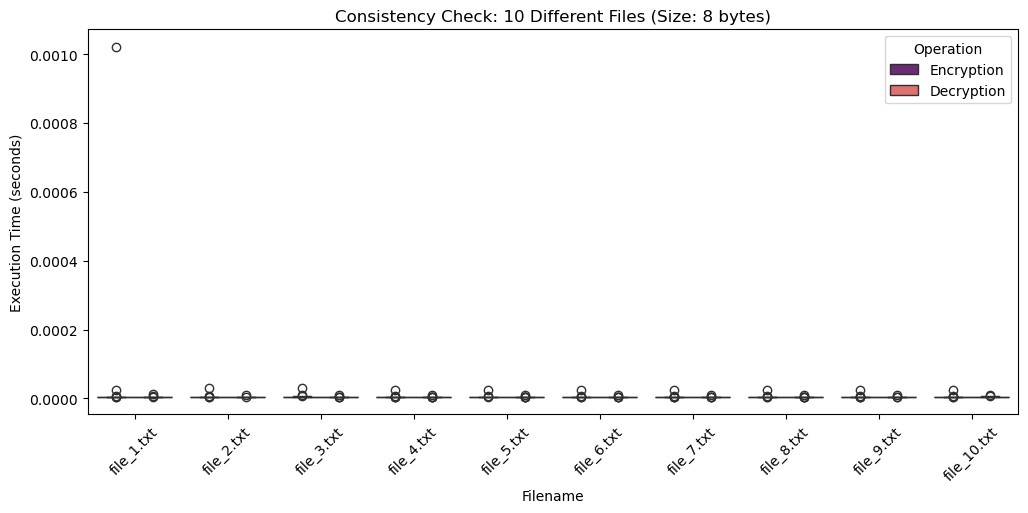

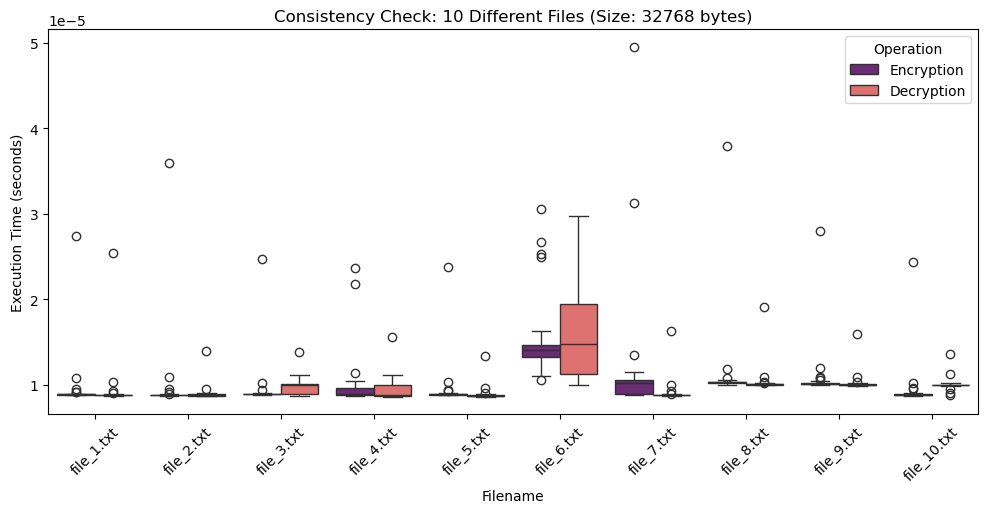

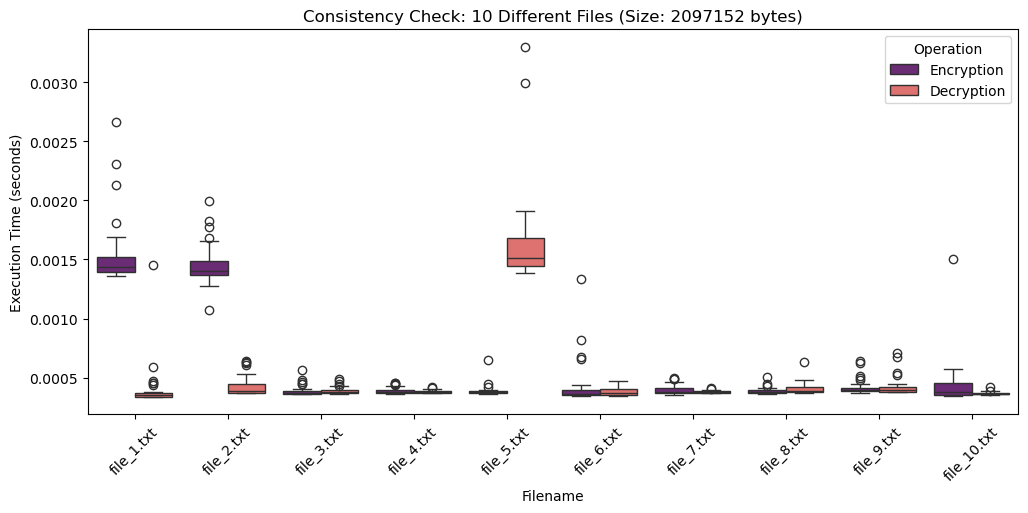

In [4]:
plot_comparison_fixed_size(df,8)
plot_comparison_fixed_size(df,32768)
plot_comparison_fixed_size(df,2097152)

&emsp; Like in analysis above, we're looking for 8 Bytes, 262144 Bytes and 2097152 Bytes sizes, but it can be done with any file size, just calling the function with the desire size in the function parameter. Studying this 3 graphics, we can conclude:
- **No, the algorithmic execution time does not change based on the file's content!** Any variations observed between different files of the same size are purely the result of the environmental noise (CPU jitter) already proven in Question B.1, not a change in the algorithm's complexity.<br>
- Because AES in Counter Mode (AES-CTR) operates on raw byte blocks, it is completely blind to the actual content (data entropy) of the files. Encrypting a 32 KB file of structured text requires the exact same number of mathematical operations as encrypting a 32 KB file of random noise. Therefore, while the measured time fluctuates due to OS background tasks (as seen in the spikes of file_8 for 32 KB or file_1 for 2 MB), the theoretical and practical computational workload of the algorithm remains perfectly constant."

##### Final Analysis - Cross-size graphic:
<br>For end AES-CTR analysis, let's put all performances times by file size side by side in a log scale graphic:

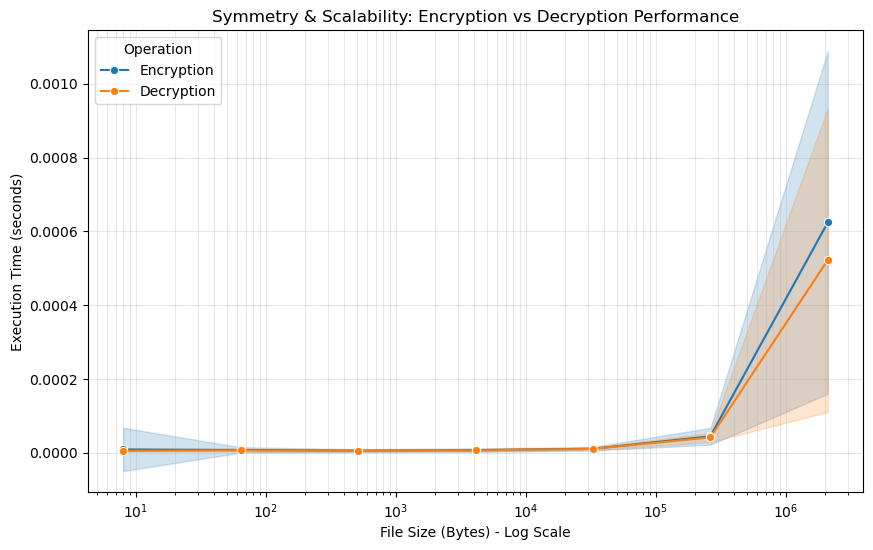

In [5]:
plot_final_scalability(df)

&emsp;Studying this graphic, we can conclude:
1) **Algorithmic Symmetry:** The near-perfect overlap of the encryption (blue) and decryption (orange) plot lines demonstrates the symmetric workload of the AES Counter Mode. Because both operations simply generate a keystream (Key + Nonce) and apply an XOR bitwise operation against the payload, they are computationally indistinguishable and require the exact same execution time.
2) **Linear Time Complexity O(n):** While the plot visually resembles an exponential curve, it is plotted against a logarithmic X-axis. Mathematically, a straight linear progression plotted on a logarithmic scale produces this exact curve. This empirically proves that AES-CTR scales linearly **O(n)**: the execution time grows in direct, steady proportion to the input byte size, without exponential performance degradation.
3) **Variance Expansion:** The shaded confidence intervals (representing standard deviation across the n=30 sample size) visually widen as the file size increases. This corroborates our earlier findings: larger files demand longer execution windows and memory fetches (RAM), exponentially increasing the likelihood of Operating System interruptions, which causes the execution times to fluctuate more broadly than with smaller payloads.
